In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
features_final = pd.read_csv("../../../data/extracted_features_extended_mean_blood.csv")
train_groups = ['a', 'b', 'c', 'd']
train_features = features_final[features_final['group_id'].isin(train_groups)]
testing_features = features_final[features_final['group_id']== "e"]
feature_cols = ["Asymmetry", "Compactness", "Convexity", "Multicolor", "red_pixels", "blue_pixels", "mean_red", "mean_blue", "Entropy", "Hue_Var", "Sat_Var", "Val_Var","2_3_lesions", "hair_feature", "blood_pixels", "blood_detected"]

train_df = train_features[feature_cols + ["Class"]].copy()
train_df["label"] = train_df["Class"].astype(int)
train_df = train_df.drop(columns=["Class"])


In [2]:
#Extract X, y, and groups (for GroupKFold)
# Training data (groups a–d)
X_train = train_features[feature_cols].values
y_train = train_features["Class"].astype(int).values
groups_train = train_features["group_id"].values   # a, b, c, d

# Testing data (group e)
X_test = testing_features[feature_cols].values
y_test = testing_features["Class"].astype(int).values

In [ ]:
#kNN model
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline


knn = KNeighborsClassifier()


pipe = Pipeline([
    ("scaler", StandardScaler()),  
    ("feature_selector", SequentialFeatureSelector(
        knn,
        direction="forward",       
        n_features_to_select="auto" 
    )),
    ("knn", knn)                   
])


In [ ]:

pipe.fit(X_train, y_train)


selector = pipe.named_steps["feature_selector"]


mask = selector.get_support()


selected_features = [f for f, m in zip(feature_cols, mask) if m]
print("Selected features:", selected_features)


Selected features: ['Asymmetry', 'Compactness', 'red_pixels', 'blue_pixels', 'Hue_Var', '2_3_lesions', 'blood_pixels', 'blood_detected']


In [ ]:


param_grid = {
    "feature_selector__n_features_to_select": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}


In [ ]:
from sklearn.model_selection import GroupKFold, GridSearchCV


cv = GroupKFold(n_splits=4)   


grid = GridSearchCV(
    estimator=pipe,                
    param_grid=param_grid,          
    cv=cv,                          
    scoring="f1",                   
    n_jobs=-1,                      
    verbose=2                       
)


grid.fit(X_train, y_train, groups=groups_train)

print("Best parameters:", grid.best_params_)
print("Best CV f1 score:", grid.best_score_)


Fitting 4 folds for each of 360 candidates, totalling 1440 fits
[CV] END feature_selector__n_features_to_select=1, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.1s
[CV] END feature_selector__n_features_to_select=1, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.2s
[CV] END feature_selector__n_features_to_select=1, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.1s
[CV] END feature_selector__n_features_to_select=1, knn__metric=euclidean, knn__n_neighbors=5, knn__weights=uniform; total time=   0.1s
[CV] END feature_selector__n_features_to_select=1, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.1s
[CV] END feature_selector__n_features_to_select=1, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.1s
[CV] END feature_selector__n_features_to_select=1, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total t

In [ ]:
best_pipe = grid.best_estimator_

selector = best_pipe.named_steps["feature_selector"]
mask = selector.get_support()

selected_features = [f for f, m in zip(feature_cols, mask) if m]
print("Selected features:", selected_features)
print("Number of selected features:", sum(mask))

print("All final parameters:")
for param, value in best_pipe.get_params().items():
    print(param, ":", value)

print("Best hyperparameters:", grid.best_params_)


probs = best_pipe.predict_proba(X_train)[:, 1]
print("Example probabilities:", probs[:10])

print(best_pipe)


Selected features: ['Asymmetry']
Number of selected features: 1
All final parameters:
memory : None
steps : [('scaler', StandardScaler()), ('feature_selector', SequentialFeatureSelector(estimator=KNeighborsClassifier(),
                          n_features_to_select=1)), ('knn', KNeighborsClassifier(metric='euclidean', n_neighbors=15))]
transform_input : None
verbose : False
scaler : StandardScaler()
feature_selector : SequentialFeatureSelector(estimator=KNeighborsClassifier(),
                          n_features_to_select=1)
knn : KNeighborsClassifier(metric='euclidean', n_neighbors=15)
scaler__copy : True
scaler__with_mean : True
scaler__with_std : True
feature_selector__cv : 5
feature_selector__direction : forward
feature_selector__estimator__algorithm : auto
feature_selector__estimator__leaf_size : 30
feature_selector__estimator__metric : minkowski
feature_selector__estimator__metric_params : None
feature_selector__estimator__n_jobs : None
feature_selector__estimator__n_neighbors 

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

def print_metrics(y_test, y_pred, y_prob):
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score: {f1:.4f}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAUC:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
[[ 76 102]
 [ 82 113]]

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.43      0.45       178
           1       0.53      0.58      0.55       195

    accuracy                           0.51       373
   macro avg       0.50      0.50      0.50       373
weighted avg       0.50      0.51      0.50       373


AUC: 0.5331604724863153


In [9]:
print_metrics(y_test, y_pred, y_prob)

Accuracy: 0.5067
Recall: 0.5795
AUC: 0.5332
Precision: 0.5256
F1 Score: 0.5512


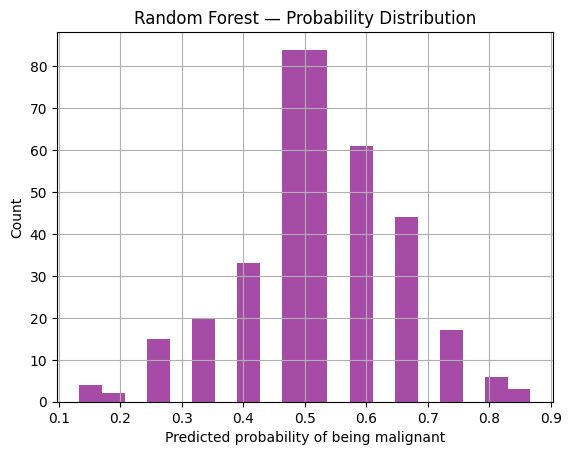

In [10]:
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=20, color='purple', alpha=0.7)
plt.xlabel("Predicted probability of being malignant")
plt.ylabel("Count")
plt.title("Random Forest — Probability Distribution")
plt.grid(True)
plt.show()


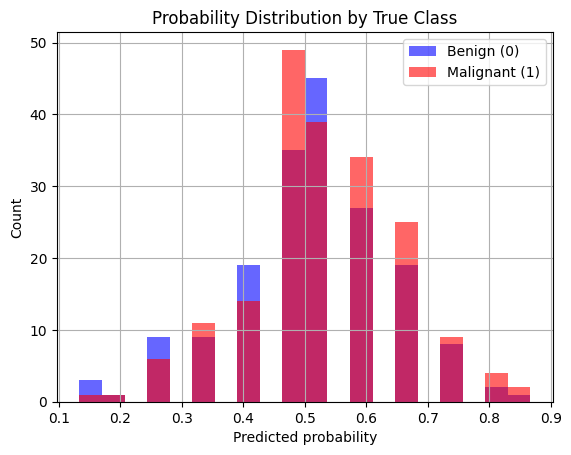

In [11]:
malignant_probs = y_prob[y_test == 1]
benign_probs = y_prob[y_test == 0]

plt.hist(benign_probs, bins=20, alpha=0.6, label="Benign (0)", color="blue")
plt.hist(malignant_probs, bins=20, alpha=0.6, label="Malignant (1)", color="red")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Probability Distribution by True Class")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
X_all = features_final[feature_cols].values
features_final["probability_malignant"] = grid.predict_proba(X_all)[:, 1]
features_final.to_csv("../../../data/features_with_probabilities_extended_blood.csv", index=False)
